# 2. A small model zoo, calibration, and ABP reconstruction

On the bundled VitalDB mini subset (official patient-disjoint splits). Four regressors and
two reconstruction models, all trained in a couple of minutes:

1. **1-D CNN**, **local self-attention**, **local cross-attention (PTT)** -- with train/val
   convergence curves and test MAE.
2. **Calibration** -- per-subject offset turns the near-baseline model into an accurate one,
   while the **causal PTT audit stays unchanged** (accurate is not faithful).
3. **ABP reconstruction** -- conv and **cross-attention** variants rebuild the arterial


In [1]:
import numpy as np, matplotlib.pyplot as plt, torch, torch.nn as nn
import mechlib
plt.rcParams.update({"axes.spines.top":False,"axes.spines.right":False,"font.size":10})
NAVY,RED,GREEN,ORANGE = "#2f4b7c","#c1543b","#3b8c5a","#d99a2b"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d = mechlib.load_mini("data/vitaldb_mini.npz")
ECG, PPG, ABP = mechlib.ECG, mechlib.PPG, mechlib.ABP
Xtr, ytr = mechlib.normalize(d["Xtr"][:,:,[ECG,PPG]]), d["ytr"]
Xva, yva = mechlib.normalize(d["Xva"][:,:,[ECG,PPG]]), d["yva"]
Xte, yte, gte = mechlib.normalize(d["Xte"][:,:,[ECG,PPG]]), d["yte"], d["gte"]
fs = d["fs"]
BP_MU, BP_SD = ytr.mean(0), ytr.std(0)
def Tn(a): return torch.tensor(a, device=device)
Xt, yt = Tn(Xtr), Tn((ytr-BP_MU)/BP_SD)
Xv, yv = Tn(Xva), Tn((yva-BP_MU)/BP_SD); Xe = Tn(Xte)
print("splits:  train", len(Xtr), " val", len(Xva), " test", len(Xte), "  device:", device)

splits:  train 4000  val 1200  test 1200   device: cuda


In [2]:
def evalse(model, X, y_s):
    model.eval(); out=[]
    with torch.no_grad():
        for s in range(0,len(X),512): out.append(((model(X[s:s+512])-y_s[s:s+512])**2).mean(1))
    return torch.cat(out).mean().item()
def test_pred(model):
    model.eval(); out=[]
    with torch.no_grad():
        for s in range(0,len(Xe),512): out.append(model(Xe[s:s+512]).cpu().numpy())
    return np.concatenate(out)*BP_SD + BP_MU
def run(model, epochs=40, lr=2e-3, bs=128, tag=""):
    model=model.to(device); opt=torch.optim.Adam(model.parameters(), lr); hist={"tr":[],"va":[]}
    for ep in range(epochs):
        model.train(); perm=torch.randperm(len(Xt)); tot=0.0
        for s in range(0,len(Xt),bs):
            b=perm[s:s+bs]; loss=((model(Xt[b])-yt[b])**2).mean()
            opt.zero_grad(); loss.backward(); opt.step(); tot+=loss.item()*len(b)
        hist["tr"].append(tot/len(Xt)); hist["va"].append(evalse(model,Xv,yv))
    mae=np.abs(test_pred(model)-yte).mean(0); n=sum(p.numel() for p in model.parameters())
    print(f"{tag:>26}  params {n/1e3:5.0f}k   test MAE  SBP {mae[0]:5.1f}  DBP {mae[1]:5.1f} mmHg")
    return hist, mae

## Three regressors

CNN; local **self-attention** (banded mask, tokens attend within a window); local
**cross-attention** where PPG tokens attend to nearby ECG tokens, so the learned span is


In [3]:
class SmallCNN(nn.Module):
    def __init__(self, w=32):
        super().__init__()
        self.net=nn.Sequential(nn.Conv1d(2,w,7,2,3),nn.ReLU(),nn.Conv1d(w,w*2,7,2,3),nn.ReLU(),
            nn.Conv1d(w*2,w*2,7,2,3),nn.ReLU(),nn.AdaptiveAvgPool1d(1),nn.Flatten(),nn.Linear(w*2,2))
    def forward(self,x): return self.net(x.transpose(1,2))

def banded(Tk, win, dev):
    i=torch.arange(Tk,device=dev); return (i[None,:]-i[:,None]).abs()>win

class LocalSelfAttn(nn.Module):
    def __init__(self,d=64,heads=4,layers=2,win=8):
        super().__init__()
        self.stem=nn.Sequential(nn.Conv1d(2,d,7,4,3),nn.GELU(),nn.Conv1d(d,d,7,4,3),nn.GELU())
        with torch.no_grad(): self.T=self.stem(torch.zeros(1,2,1250)).shape[-1]
        self.pos=nn.Parameter(0.02*torch.randn(1,self.T,d))
        self.enc=nn.TransformerEncoder(nn.TransformerEncoderLayer(d,heads,d*2,0.1,batch_first=True,norm_first=True),
                                       layers, enable_nested_tensor=False)
        self.head=nn.Linear(d,2); self.win=win
    def forward(self,x):
        h=self.stem(x.transpose(1,2)).transpose(1,2)+self.pos
        return self.head(self.enc(h, mask=banded(self.T,self.win,x.device)).mean(1))

class LocalCrossAttn(nn.Module):
    def __init__(self,d=64,heads=4,win=8):
        super().__init__()
        mk=lambda: nn.Sequential(nn.Conv1d(1,d,7,4,3),nn.GELU(),nn.Conv1d(d,d,7,4,3),nn.GELU())
        self.se,self.sp=mk(),mk()
        with torch.no_grad(): self.T=self.se(torch.zeros(1,1,1250)).shape[-1]
        self.pe=nn.Parameter(0.02*torch.randn(1,self.T,d)); self.pp=nn.Parameter(0.02*torch.randn(1,self.T,d))
        self.cross=nn.MultiheadAttention(d,heads,dropout=0.1,batch_first=True); self.norm=nn.LayerNorm(d)
        self.ffn=nn.Sequential(nn.LayerNorm(d),nn.Linear(d,d*2),nn.GELU(),nn.Linear(d*2,d))
        self.head=nn.Linear(d,2); self.win=win
    def forward(self,x):
        e=self.se(x[:,:,0:1].transpose(1,2)).transpose(1,2)+self.pe
        p=self.sp(x[:,:,1:2].transpose(1,2)).transpose(1,2)+self.pp
        a,_=self.cross(p,e,e,attn_mask=banded(self.T,self.win,x.device),need_weights=False)
        h=self.norm(p+a); h=h+self.ffn(h); return self.head(h.mean(1))

torch.manual_seed(0); h_cnn,mae_cnn = run(SmallCNN(),tag="1-D CNN")
torch.manual_seed(0); h_sa,mae_sa  = run(LocalSelfAttn(),tag="local self-attention")
torch.manual_seed(0); cross=LocalCrossAttn(); h_ca,mae_ca = run(cross,tag="local cross-attention (PTT)")

                   1-D CNN  params    44k   test MAE  SBP  13.7  DBP   8.9 mmHg


      local self-attention  params   102k   test MAE  SBP  15.9  DBP  10.3 mmHg


local cross-attention (PTT)  params   102k   test MAE  SBP  15.2  DBP   9.6 mmHg


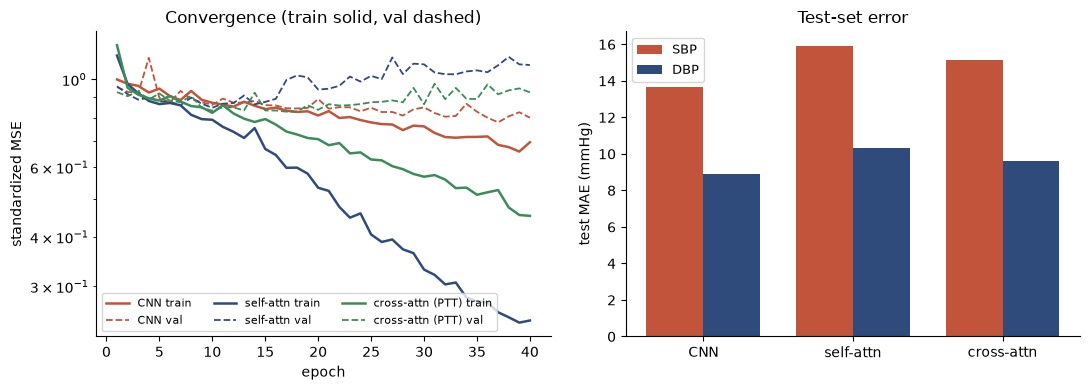

In [4]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for h,c,lab in [(h_cnn,RED,"CNN"),(h_sa,NAVY,"self-attn"),(h_ca,GREEN,"cross-attn (PTT)")]:
    ep=np.arange(1,len(h["tr"])+1)
    ax[0].plot(ep,h["tr"],color=c,lw=1.8,label=f"{lab} train"); ax[0].plot(ep,h["va"],color=c,lw=1.3,ls="--",label=f"{lab} val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("standardized MSE"); ax[0].set_yscale("log")
ax[0].set_title("Convergence (train solid, val dashed)"); ax[0].legend(fontsize=8,ncol=3)
names=["CNN","self-attn","cross-attn"]; maes=[mae_cnn,mae_sa,mae_ca]; x=np.arange(3); w=0.38
ax[1].bar(x-w/2,[m[0] for m in maes],w,color=RED,label="SBP"); ax[1].bar(x+w/2,[m[1] for m in maes],w,color=NAVY,label="DBP")
ax[1].set_xticks(x); ax[1].set_xticklabels(names); ax[1].set_ylabel("test MAE (mmHg)")
ax[1].set_title("Test-set error"); ax[1].legend(fontsize=9); fig.tight_layout(); plt.show()

## Calibration: accurate is not faithful

The raw model is near the predict-the-mean baseline (a single amplitude-normalized window
can't fix a subject's absolute BP). A **per-subject offset** (from a few anchor segments)
makes it genuinely accurate. But an offset is constant, so it leaves the **causal PTT audit


In [5]:
pred = test_pred(SmallCNN().to(device)) * 0  # placeholder
# use the trained CNN
torch.manual_seed(0); cnn=SmallCNN().to(device); opt=torch.optim.Adam(cnn.parameters(),2e-3)
for ep in range(40):
    cnn.train(); perm=torch.randperm(len(Xt))
    for s in range(0,len(Xt),128):
        b=perm[s:s+128]; loss=((cnn(Xt[b])-yt[b])**2).mean(); opt.zero_grad(); loss.backward(); opt.step()
pred = test_pred(cnn)
base = np.abs(yte - ytr.mean(0)).mean(0)
raw  = np.abs(pred - yte).mean(0)
cal  = mechlib.calibrated_mae(pred, yte, gte, K=3)
print(f"predict-mean baseline   SBP {base[0]:.1f}  DBP {base[1]:.1f} mmHg")
print(f"raw model               SBP {raw[0]:.1f}  DBP {raw[1]:.1f} mmHg")
print(f"+ per-subject calibration SBP {cal[0]:.1f}  DBP {cal[1]:.1f} mmHg   <- accurate")
au = mechlib.causal_ptt_audit(cnn, Xte, fs, device, ppg_pos=1)
print(f"\ncausal PTT audit: dBP/dPTT {au['dBP_dPTT']:+.2f} mmHg/s  "
      f"frac correct sign {au['frac_correct_sign']:.2f}  (physiological = negative)  <- still unfaithful")

predict-mean baseline   SBP 14.8  DBP 9.5 mmHg
raw model               SBP 13.7  DBP 8.9 mmHg
+ per-subject calibration SBP 10.6  DBP 6.2 mmHg   <- accurate

causal PTT audit: dBP/dPTT -0.71 mmHg/s  frac correct sign 0.60  (physiological = negative)  <- still unfaithful


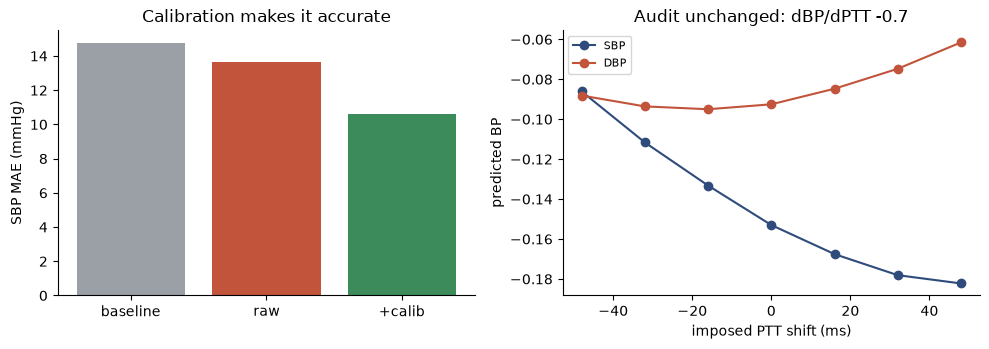

In [6]:
fig,ax=plt.subplots(1,2,figsize=(10,3.6))
ax[0].bar(["baseline","raw","+calib"],[base[0],raw[0],cal[0]],color=["#9aa0a6",RED,GREEN])
ax[0].set_ylabel("SBP MAE (mmHg)"); ax[0].set_title("Calibration makes it accurate")
ax[1].plot(au["shift_ms"],au["curve_sbp"],"-o",color=NAVY,label="SBP"); ax[1].plot(au["shift_ms"],au["curve_dbp"],"-o",color=RED,label="DBP")
ax[1].set_xlabel("imposed PTT shift (ms)"); ax[1].set_ylabel("predicted BP")
ax[1].set_title(f"Audit unchanged: dBP/dPTT {au['dBP_dPTT']:+.1f}"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## ABP reconstruction: conv vs cross-attention

Channel 2 is the arterial pressure waveform -- never an input (that would leak the answer),
but an ideal reconstruction target. We rebuild the ABP *shape* (per-segment standardized)
from ECG + PPG two ways: a conv encoder-decoder, and a **cross-attention** model where ECG


In [7]:
def stdz(w):
    w=w.astype(np.float32).copy(); w-=w.mean(1,keepdims=True); w/=w.std(1,keepdims=True)+1e-8; return w
Atr=Tn(stdz(d["Xtr"][:,:,ABP])); Ava=Tn(stdz(d["Xva"][:,:,ABP])); Ate=Tn(stdz(d["Xte"][:,:,ABP]))

class ConvRecon(nn.Module):
    def __init__(self,w=32):
        super().__init__()
        self.enc=nn.Sequential(nn.Conv1d(2,w,7,2,3),nn.GELU(),nn.Conv1d(w,w*2,7,2,3),nn.GELU(),nn.Conv1d(w*2,w*2,7,2,3),nn.GELU())
        self.dec=nn.Sequential(nn.ConvTranspose1d(w*2,w*2,7,2,3,output_padding=1),nn.GELU(),
            nn.ConvTranspose1d(w*2,w,7,2,3,output_padding=1),nn.GELU(),nn.ConvTranspose1d(w,1,7,2,3,output_padding=1))
    def forward(self,x):
        z=self.enc(x.transpose(1,2)); y=self.dec(z)
        return nn.functional.interpolate(y,size=x.shape[1],mode="linear",align_corners=False).squeeze(1)

class CrossRecon(nn.Module):
    def __init__(self,d=48,heads=4):
        super().__init__()
        mk=lambda: nn.Sequential(nn.Conv1d(1,d,7,4,3),nn.GELU())          # 1250 -> ~313 tokens
        self.se,self.sp=mk(),mk()
        self.ce=nn.MultiheadAttention(d,heads,batch_first=True); self.cp=nn.MultiheadAttention(d,heads,batch_first=True)
        self.norm=nn.LayerNorm(d)
        self.dec=nn.Sequential(nn.ConvTranspose1d(d,d,7,4,3,output_padding=3),nn.GELU(),nn.Conv1d(d,1,7,1,3))
    def forward(self,x):
        e=self.se(x[:,:,0:1].transpose(1,2)).transpose(1,2)                # ECG tokens (B,T,d)
        p=self.sp(x[:,:,1:2].transpose(1,2)).transpose(1,2)                # PPG tokens
        pe,_=self.ce(p,e,e,need_weights=False); ep,_=self.cp(e,p,p,need_weights=False)  # mutual cross-attn
        h=self.norm(pe+ep).transpose(1,2)                                 # (B,d,T)
        y=self.dec(h)
        return nn.functional.interpolate(y,size=x.shape[1],mode="linear",align_corners=False).squeeze(1)

def train_recon(model, epochs=30):
    model=model.to(device); opt=torch.optim.Adam(model.parameters(),2e-3); h={"tr":[],"va":[]}
    for ep in range(epochs):
        model.train(); perm=torch.randperm(len(Xt)); tot=0.0
        for s in range(0,len(Xt),128):
            b=perm[s:s+128]; loss=((model(Xt[b])-Atr[b])**2).mean()
            opt.zero_grad(); loss.backward(); opt.step(); tot+=loss.item()*len(b)
        model.eval()
        with torch.no_grad(): va=((model(Xv)-Ava)**2).mean().item()
        h["tr"].append(tot/len(Xt)); h["va"].append(va)
    model.eval()
    with torch.no_grad(): pr=model(Xe).cpu().numpy()
    tr=Ate.cpu().numpy(); corr=np.mean([np.corrcoef(pr[i],tr[i])[0,1] for i in range(len(pr))])
    return h, pr, tr, corr

torch.manual_seed(0); hc,pc,tc,corr_c = train_recon(ConvRecon())
torch.manual_seed(0); hx,px,tx,corr_x = train_recon(CrossRecon())
print(f"ABP reconstruction test corr  conv {corr_c:.2f}   cross-attention {corr_x:.2f}  (1.0 = perfect shape)")

ABP reconstruction test corr  conv 0.93   cross-attention 0.88  (1.0 = perfect shape)


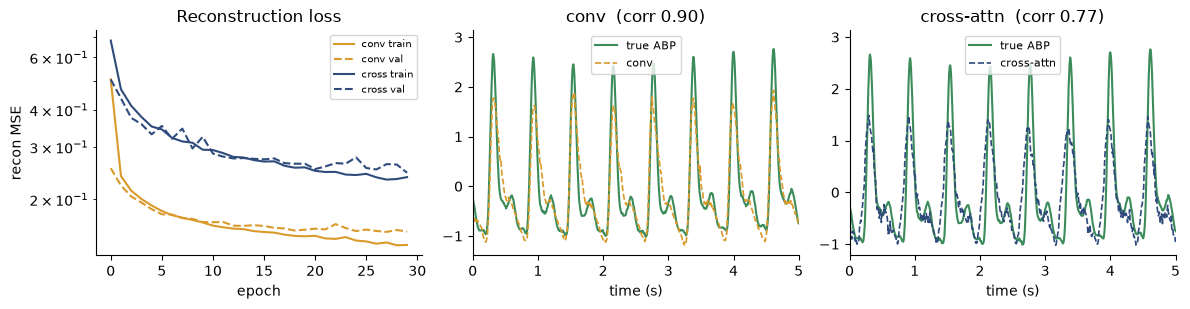

In [8]:
fig,ax=plt.subplots(1,3,figsize=(12,3.2))
ax[0].plot(hc["tr"],color=ORANGE,label="conv train"); ax[0].plot(hc["va"],color=ORANGE,ls="--",label="conv val")
ax[0].plot(hx["tr"],color=NAVY,label="cross train"); ax[0].plot(hx["va"],color=NAVY,ls="--",label="cross val")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("recon MSE"); ax[0].set_title("Reconstruction loss"); ax[0].legend(fontsize=7)
tt=np.arange(pc.shape[1])/fs
for k,(pr,corr,nm,c) in enumerate([(pc,corr_c,"conv",ORANGE),(px,corr_x,"cross-attn",NAVY)]):
    ax[k+1].plot(tt,tc[0],color=GREEN,lw=1.5,label="true ABP"); ax[k+1].plot(tt,pr[0],color=c,lw=1.2,ls="--",label=nm)
    ax[k+1].set_xlim(0,5); ax[k+1].set_xlabel("time (s)"); ax[k+1].set_title(f"{nm}  (corr {np.corrcoef(pr[0],tc[0])[0,1]:.2f})"); ax[k+1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## Predicting SBP / DBP from the reconstruction

Reconstruct ABP in real **mmHg** (target not standardized) and read the labels off the wave:


reconstruct-then-read-off  test MAE  SBP 14.5  DBP 22.6 mmHg   (direct CNN SBP 13.7)


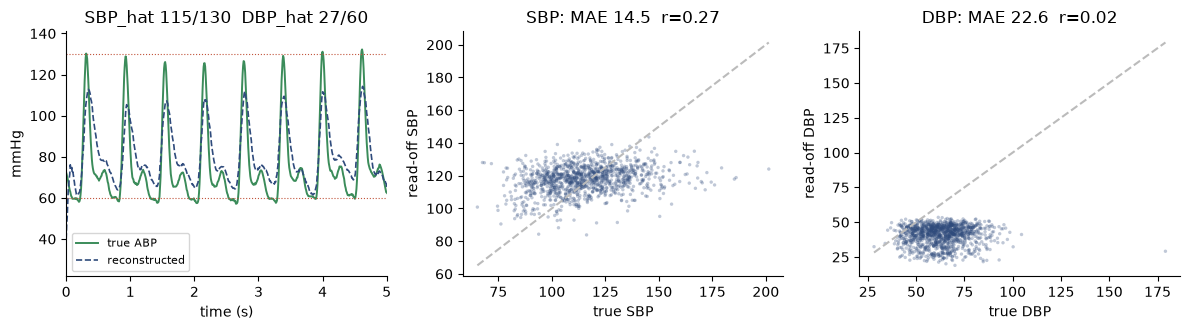

In [9]:
Mtr=Tn(d["Xtr"][:,:,ABP]); Mva=Tn(d["Xva"][:,:,ABP])
torch.manual_seed(0); rec=ConvRecon().to(device); opt=torch.optim.Adam(rec.parameters(),2e-3)
for ep in range(40):
    rec.train(); perm=torch.randperm(len(Xt))
    for s in range(0,len(Xt),128):
        b=perm[s:s+128]; loss=((rec(Xt[b])-Mtr[b])**2).mean(); opt.zero_grad(); loss.backward(); opt.step()
rec.eval()
with torch.no_grad(): predm=rec(Xe).cpu().numpy()
sbp_hat,dbp_hat = predm.max(1), predm.min(1)
mae_r=np.array([np.abs(sbp_hat-yte[:,0]).mean(), np.abs(dbp_hat-yte[:,1]).mean()])
print(f"reconstruct-then-read-off  test MAE  SBP {mae_r[0]:.1f}  DBP {mae_r[1]:.1f} mmHg   (direct CNN SBP {mae_cnn[0]:.1f})")
fig,ax=plt.subplots(1,3,figsize=(12,3.4)); tt=np.arange(predm.shape[1])/fs
ax[0].plot(tt,d["Xte"][0,:,ABP],color=GREEN,lw=1.4,label="true ABP"); ax[0].plot(tt,predm[0],color=NAVY,ls="--",lw=1.2,label="reconstructed")
ax[0].axhline(yte[0,0],color=RED,lw=.8,ls=":"); ax[0].axhline(yte[0,1],color=RED,lw=.8,ls=":")
ax[0].set_xlim(0,5); ax[0].set_ylabel("mmHg"); ax[0].set_xlabel("time (s)")
ax[0].set_title(f"SBP_hat {sbp_hat[0]:.0f}/{yte[0,0]:.0f}  DBP_hat {dbp_hat[0]:.0f}/{yte[0,1]:.0f}"); ax[0].legend(fontsize=8)
for k,(hat,tru,nm) in enumerate([(sbp_hat,yte[:,0],"SBP"),(dbp_hat,yte[:,1],"DBP")]):
    ax[k+1].scatter(tru,hat,s=6,alpha=.3,color=NAVY,edgecolor="none"); lim=[tru.min(),tru.max()]; ax[k+1].plot(lim,lim,"--",color="#bbb")
    ax[k+1].set_xlabel(f"true {nm}"); ax[k+1].set_ylabel(f"read-off {nm}"); ax[k+1].set_title(f"{nm}: MAE {mae_r[k]:.1f}  r={np.corrcoef(tru,hat)[0,1]:.2f}")
fig.tight_layout(); plt.show()

### Summary

- Accuracy, a linear probe, and a causal audit are three different things. Calibration buys
  **accuracy**; it does not buy **faithful use of PTT** -- the causal audit is unmoved.
- ECG + PPG carry enough to rebuild the ABP pressure wave (conv and cross-attention both
  work); reading its peak/trough off gives a transparent BP estimate.
- Natural next step: pretrain with ABP/PTT reconstruction, fine-tune for BP, and re-run the
